In [1]:
print("Hello12234")

Hello12234


                    DAY -8

🐍 Python for Network Engineers — Day 8: List Comprehensions
Part 1 — The concept & why it matters
A list comprehension is a compact, one-line way to build a new list from an existing one. It rolls the "create an empty list → for loop → append" pattern (remember Day 2?) into a single readable expression.
The shape is: [ expression for item in iterable if condition ] — read it as "give me expression for every item in the collection, but only if condition is true." The if part is optional.
Why it matters for network engineering: our daily work is full of "take this list and transform/filter it" — pull every down interface from a status list, strip whitespace off lines of show output, build a list of management IPs from an inventory, or grab only the VLANs above 100. Comprehensions make that crisp and far easier to read than a multi-line loop. You'll see them everywhere in real automation code, so recognizing and writing them is a genuine intermediate milestone.
Part 2 — Example code
① The basic transform — build one list from another:
octets = ["10", "0", "0", "1"]
# turn each string into an int
numbers = [int(o) for o in octets]
print(numbers)            # [10, 0, 0, 1]
# build interface config names
ports = [1, 2, 3]
intf = [f"GigabitEthernet0/{p}" for p in ports]
print(intf)               # ['GigabitEthernet0/1', 'GigabitEthernet0/2', 'GigabitEthernet0/3']
② Add an if to filter — keep only what matches:
interfaces = {
    "Gi0/1": "up",
    "Gi0/2": "down",
    "Gi0/3": "up",
    "Gi0/4": "down",
}
# only the interfaces that are DOWN (compare to the Day 3 loop — same result, one line!)
down = [name for name, state in interfaces.items() if state == "down"]
print(down)               # ['Gi0/2', 'Gi0/4']
③ A real-world favorite — clean up messy CLI output:
raw = ["  10.1.1.1  ", "", "10.1.1.2", "   ", "10.1.1.3 "]
# strip whitespace AND drop the blank lines in one shot
clean = [line.strip() for line in raw if line.strip()]
print(clean)              # ['10.1.1.1', '10.1.1.2', '10.1.1.3']
That third example is the pattern you'll reach for constantly when parsing the output of show commands.
Part 3 — Practice question
You're given a list of VLAN IDs pulled from a switch:
vlans = [1, 10, 20, 105, 200, 4094, 50]
👉 Using a single list comprehension, build a new list called user_vlans that contains only the VLANs greater than 100. Expected result: [105, 200, 4094].
Bonus: write a second comprehension that produces the names for those VLANs as strings like "VLAN105", "VLAN200", "VLAN4094" (hint: combine an f-string with the if filter).
Reply with your solution and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes


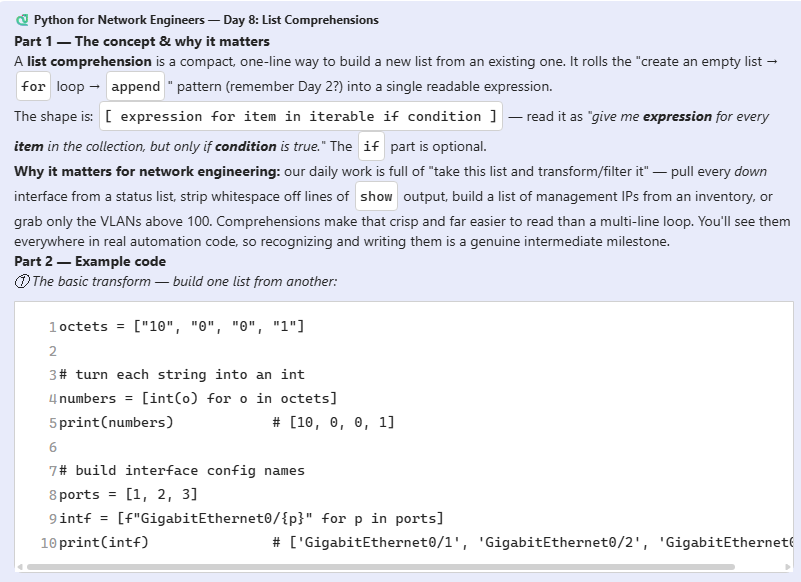

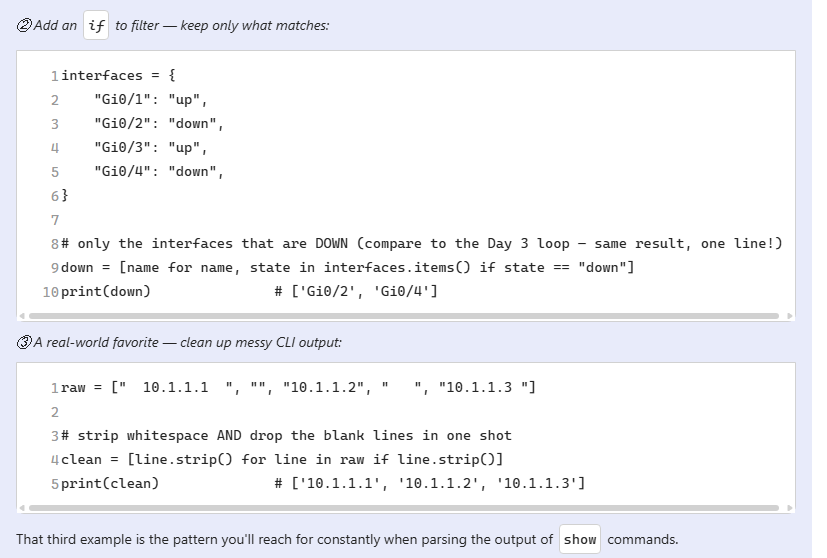

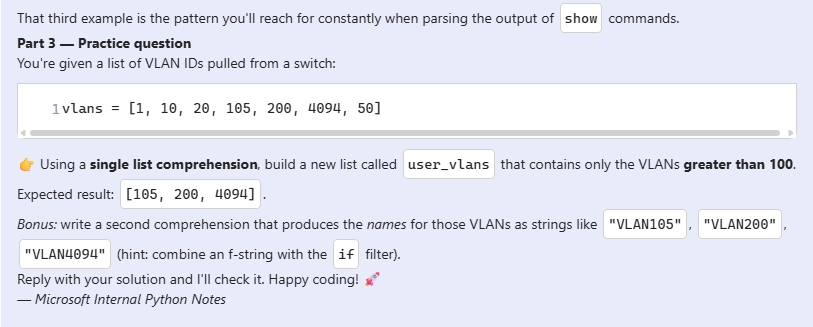

In [2]:
octets = ["10", "0", "0", "1"]

#turn each string into an int

numbers = [int(o) for o in octets]

print(numbers)

[10, 0, 0, 1]


In [6]:
octets = ["10", "0", "0", "1", "-1"]

#turn each string into an int

numbers = [int(o) for o in octets]

print(numbers)

[10, 0, 0, 1, -1]


In [5]:
octets = ["10", "0", "0", "1", "-1", "0.004"]

#turn each string into an int

numbers = [int(o) for o in octets]

print(numbers)

ValueError: invalid literal for int() with base 10: '0.004'

In [7]:
#build interface config names 

ports = [1, 2, 3]

intf = [f"GigabitEthernet0/{p}" for p in ports]
print(intf)

['GigabitEthernet0/1', 'GigabitEthernet0/2', 'GigabitEthernet0/3']


In [10]:
port = [1, 10, 30, 45, 443, 80, 22, 23, 53, 25, 69, 68, 161, 162]

intef = [f"portnumbers are{q}" for q in port]
print(intef)

['portnumbers are1', 'portnumbers are10', 'portnumbers are30', 'portnumbers are45', 'portnumbers are443', 'portnumbers are80', 'portnumbers are22', 'portnumbers are23', 'portnumbers are53', 'portnumbers are25', 'portnumbers are69', 'portnumbers are68', 'portnumbers are161', 'portnumbers are162']


In [13]:
port = [1, 10, 30, 45, 443, 80, 22, 23, 53, 25, 69, 68, 161, 162]

intef = [f"portnumbers are{q}" for q in port]
print("\n".join(intef))

portnumbers are1
portnumbers are10
portnumbers are30
portnumbers are45
portnumbers are443
portnumbers are80
portnumbers are22
portnumbers are23
portnumbers are53
portnumbers are25
portnumbers are69
portnumbers are68
portnumbers are161
portnumbers are162


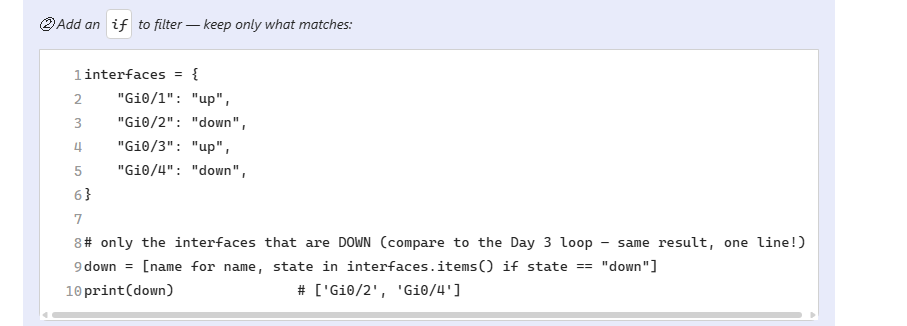

In [15]:
interfaces = {
    "Gi0/1" : "up",
    "Gi0/2" : "down",
    "Gi0/3" : "up",
    "Gi0/4" : "down"
}

#only the interfaces that are DOWN 

down = [name for name, state in interfaces.items() if state == "down"]
print(down)

['Gi0/2', 'Gi0/4']


In [17]:
down = []

for name, state in interfaces.items():
    if state == "down":
        down.append(name)

print(down)


['Gi0/2', 'Gi0/4']


In [18]:
interfaces = {
    "Gi0/1" : "up",
    "Gi0/2" : "down",
    "Gi0/3" : "up",
    "Gi0/4" : "down"
}

down_msgs = [
    f"{name} is DOWN - check cable"
    for name, state in interfaces.items()
    if state == "down"
]

print("\n".join(down_msgs))

Gi0/2 is DOWN - check cable
Gi0/4 is DOWN - check cable


In [19]:
reason = {
    "Gi0/2": "No carrier",
    "Gi0/4": "Admin shutdown"
}

for name, state in interfaces.items():
    if state == "down":
        print(f"{name} is DOWN - {reason.get(name, 'Unknown issue')}")

Gi0/2 is DOWN - No carrier
Gi0/4 is DOWN - Admin shutdown


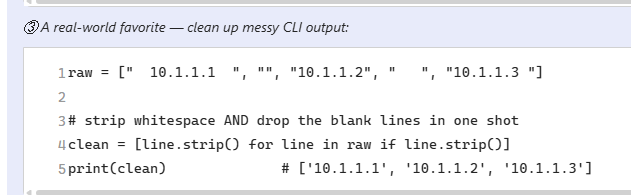

In [20]:
raw = ["    10.1.1.1    ", "", "10.1.1.2", " ", "10.1.1.3   "]

#strip whitespace AND drop the blank lines in one shot
clean = [line.strip() for line in raw if line.strip()]
print(clean)

['10.1.1.1', '10.1.1.2', '10.1.1.3']


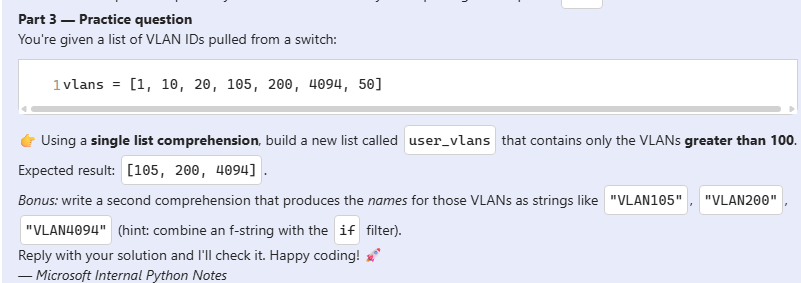

In [23]:
vlans = [1, 10, 20, 105, 200, 4094, 50]

user_vlans = []

for vlan in vlans:
    if vlan >= 100:
        print(vlan)

105
200
4094


In [24]:
vlans = [1, 10, 20, 105, 200, 4094, 50]

user_vlans = [vlan for vlan in vlans if vlan > 100]

print(user_vlans)


[105, 200, 4094]


In [25]:
vlan_names = [f"VLAN{vlan}" for vlan in vlans if vlan > 100]

print(vlan_names)


['VLAN105', 'VLAN200', 'VLAN4094']


In [1]:
print("hello")

hello


🐍 Python for Network Engineers — Day 9: Regular Expressions (the re module)
Part 1 — The concept & why it matters
A regular expression (regex) is a tiny pattern language for finding and extracting text. Instead of hand-slicing strings, you describe the shape of what you want — "an IP address", "an interface name", "a number after the word packets" — and let re pull it out.
Why it matters for network engineering: our job is drowning in semi-structured text — show ip interface brief, show version, syslog lines, BGP neighbor tables. APIs give clean JSON, but the CLI gives walls of text. Regex is how you reliably scrape the one value you need (an uptime, a serial number, a neighbor IP) out of that output. It's the bridge between "raw show output" and "data your script can act on."
The handful of pieces you'll use 90% of the time:
\d = a digit, \d+ = one or more digits
\w = a word character (letter/digit/underscore), \s = whitespace
. = any character, + = one-or-more, * = zero-or-more
( ... ) = a capture group — the part you want to extract
Always write patterns as raw strings: r"..." so backslashes behave
Three workhorse functions: re.search() (find the first match), re.findall() (get every match as a list), and re.sub() (find-and-replace).
Part 2 — Example code
① re.search + a capture group — pull one value out of a line:
Plain Text
import re
line = "GigabitEthernet0/1 is up, line protocol is up"
# capture the interface name at the start of the line
m = re.search(r"^(\S+) is (\w+)", line)
if m:
    print(m.group(1))   # GigabitEthernet0/1   (first group)
    print(m.group(2))   # up                   (second group)

② re.findall — grab every IP address in a blob of output:
Plain Text
output = """
  10.0.0.1        YES manual up
  10.0.0.254      YES manual up
  192.168.1.1     YES DHCP   down
"""
ips = re.findall(r"\d+\.\d+\.\d+\.\d+", output)
print(ips)   # ['10.0.0.1', '10.0.0.254', '192.168.1.1']

③ Multiple capture groups — turn a status line into structured data:
Plain Text
brief = "Gi0/1  10.0.0.1  up  up"
m = re.search(r"(\S+)\s+(\d+\.\d+\.\d+\.\d+)\s+(\w+)\s+(\w+)", brief)
if m:
    intf, ip, admin, proto = m.groups()
    print(f"{intf} -> {ip} (admin={admin}, proto={proto})")
    # Gi0/1 -> 10.0.0.1 (admin=up, proto=up)

④ re.sub — scrub/replace (e.g. mask the last octet for a report):
Plain Text
text = "host 10.0.0.42 reachable"
masked = re.sub(r"(\d+\.\d+\.\d+)\.\d+", r"\1.x", text)
print(masked)   # host 10.0.0.x reachable

Part 3 — Practice question
You've captured this line from show version:
Plain Text
line = "System uptime is 14 days, 3 hours, 22 minutes"
👉 Using a single re.search with three capture groups, extract the days, hours, and minutes as separate values, then print: Up for 14d 3h 22m.
Bonus: given a list of syslog lines, use re.findall(r"\d+\.\d+\.\d+\.\d+", ...) to collect every source IP, then wrap it in set(...) (remember Day 4!) to get the unique offenders.
Reply with your solution and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes

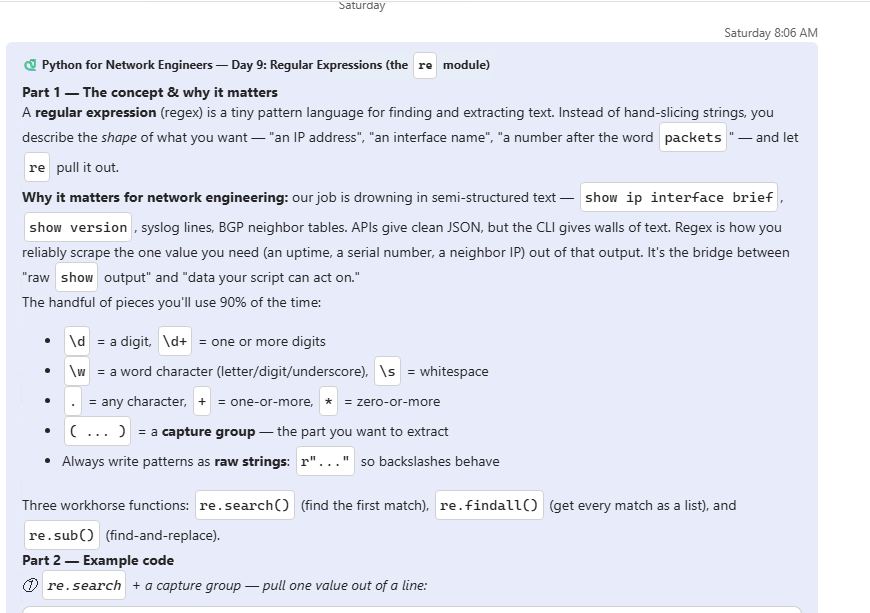



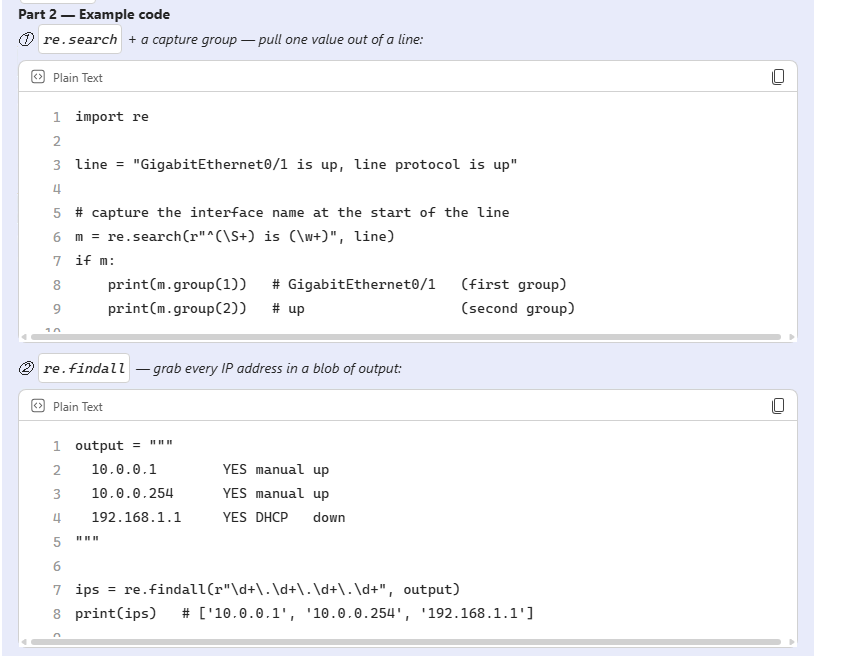


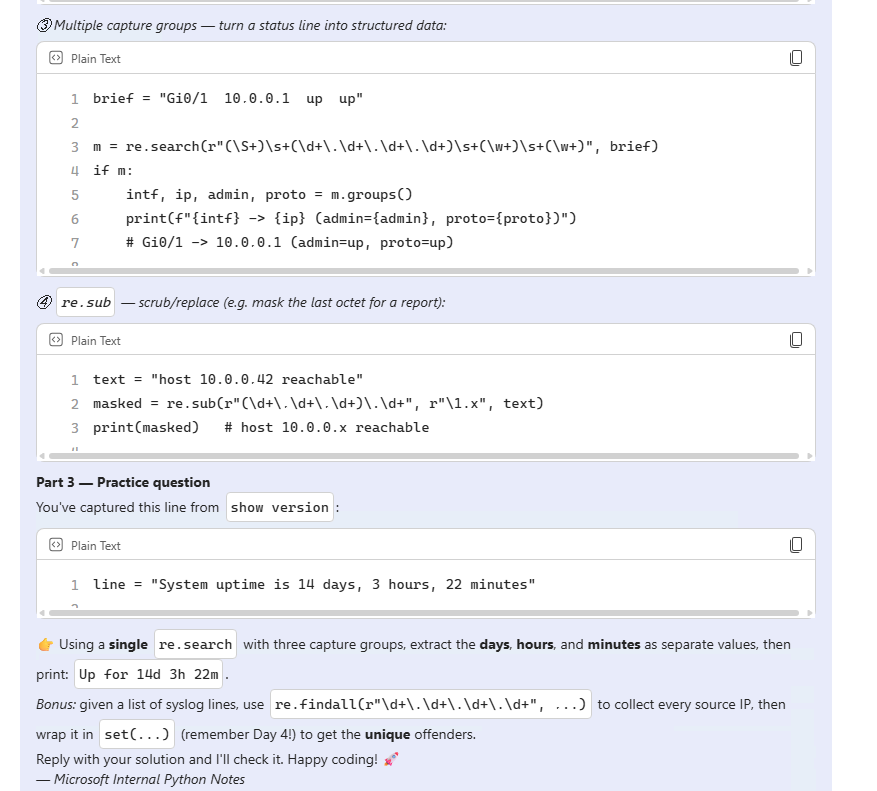





In [3]:

import re

line = "GigabitEthernet0/1 is up, line protocol is up"

#capture the interface name at the start of the line 

m = re.search(r"^(\S+) is (\w+)", line)

if m:
    print(m.group(1))      # GigabitEthernet0/1   (first group)
    print(m.group(2))         # up                   (second group)


GigabitEthernet0/1
up


In [4]:
import re

line = "GigabitEthernet0/1 is up, line protocol is up"

# capture the interface name at the start of the line
m = re.search(r"^(\S+) is (\w+)", line)
if m:
    print(m.group(1))   # GigabitEthernet0/1   (first group)
    print(m.group(2))   # up                   (second group)


GigabitEthernet0/1
up


In [7]:
import re

line = "GigabitEthernet0/1 is up, line protocol is up"

m = re.search(r"^(\S+) is (\w+), line protocol is (\w+)", line)

if m:
    print("Interface:", m.group(1))
    print("Admin status:", m.group(2))
    print("Protocol status:", m.group(3))

Interface: GigabitEthernet0/1
Admin status: up
Protocol status: up


In [8]:
import re

lines = [
    "GigabitEthernet0/1 is up, line protocol is up",
    "GigabitEthernet0/2 is down, line protocol is down",
    "GigabitEthernet0/3 is up, line protocol is down"
]

pattern = r"^(\S+) is (\w+), line protocol is (\w+)"

for line in lines:
    m = re.search(pattern, line)
    if m:
        intf = m.group(1)
        admin = m.group(2)
        protocol = m.group(3)

        print(f"{intf:25} | Admin: {admin:5} | Protocol: {protocol}")

GigabitEthernet0/1        | Admin: up    | Protocol: up
GigabitEthernet0/2        | Admin: down  | Protocol: down
GigabitEthernet0/3        | Admin: up    | Protocol: down


In [9]:
matches = re.findall(r"^(\S+) is (\w+), line protocol is (\w+)", "\n".join(lines))

for intf, admin, protocol in matches:
    print(intf, admin, protocol)

GigabitEthernet0/1 up up


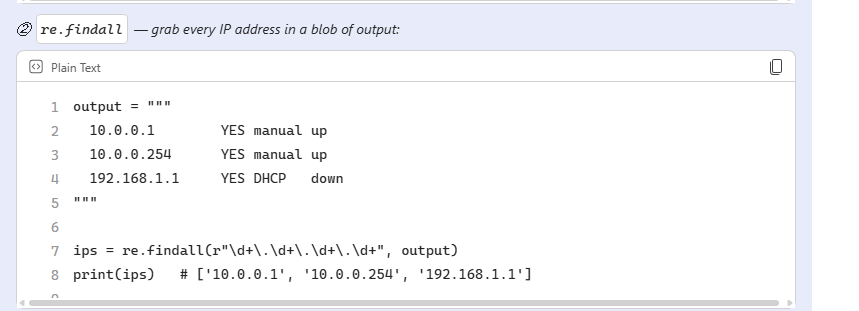

In [5]:
output = """
10.0.0.1 YES manual up
10.0.0.254 YES manual up
192.168.1.1 YES DHCP down
"""

ips = re.findall(r"\d+\. \d+\. \d+\. \d+", output)
print(ips)

[]


In [6]:
output = """
  10.0.0.1        YES manual up
  10.0.0.254      YES manual up
  192.168.1.1     YES DHCP   down
"""

ips = re.findall(r"\d+\.\d+\.\d+\.\d+", output)
print(ips)   # ['10.0.0.1', '10.0.0.254', '192.168.1.1']


['10.0.0.1', '10.0.0.254', '192.168.1.1']


In [10]:
output = """
10.0.0.1 YES manual up
10.0.0.254 YES manual up
192.168.1.1 YES DHCP down
"""

ips = re.findall(r"\d+\.\d+\.\d+\.\d+", output)
#ips = re.findall(r"\d+\. \d+\. \d+\. \d+", output)
print(ips)

['10.0.0.1', '10.0.0.254', '192.168.1.1']


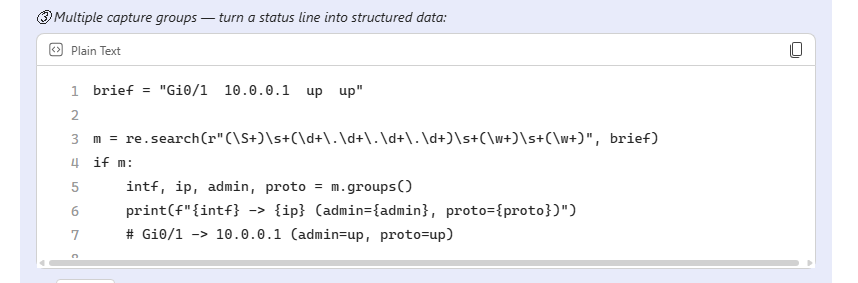

In [11]:
brief = "Gi0/1  10.0.0.1 up up"

m = re.search(r"(\S+)\s+(\d+\.\d+\.\d+\.\d+)\s+(\w+)\s+(\w+)", brief)

if m:
    intf, ip, admin, proto = m.groups()
    print(f"{intf} -> {ip} (admin={admin}, proto={proto})")
    #Gi0/1 -> 10.0.0.1 (admin=up, proto=up)

Gi0/1 -> 10.0.0.1 (admin=up, proto=up)


In [12]:
brief = "Gi0/1  10.0.0.1  up  up"

m = re.search(r"(\S+)\s+(\d+\.\d+\.\d+\.\d+)\s+(\w+)\s+(\w+)", brief)
if m:
    intf, ip, admin, proto = m.groups()
    print(f"{intf} -> {ip} (admin={admin}, proto={proto})")
    # Gi0/1 -> 10.0.0.1 (admin=up, proto=up)


Gi0/1 -> 10.0.0.1 (admin=up, proto=up)


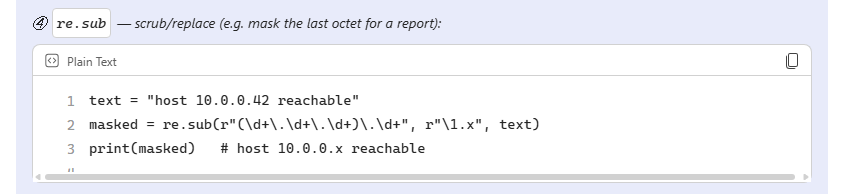

In [13]:
text = "host 10.0.0.42 reachable"

masked = re.sub(r"(\d+\.\d+\.\d+)\.\d+", r"\1.x", text)

print(masked)  #host 10.0.0.x reachable

host 10.0.0.x reachable


In [14]:
text = "host 10.0.0.42 reachable"
masked = re.sub(r"(\d+\.\d+\.\d+)\.\d+", r"\1.x", text)
print(masked)   # host 10.0.0.x reachable


host 10.0.0.x reachable


Day 10: Reading & Writing Files (File I/O with with open())
Part 1 — The concept & why it matters
So far our data has lived inside the script. Real automation reads its inputs from files (a list of device IPs, an inventory, a config template) and writes its outputs to files (a health-check report, a log, generated configs). File I/O is the bridge between your script and the world around it.
The one pattern to learn is with open(filename, mode):
"r" — read (the default)
"w" — write (creates the file, and overwrites it if it exists)
"a" — append (adds to the end, keeps what's there)
Always use the with form — it's a context manager that automatically closes the file for you, even if an error happens midway. No more forgotten f.close().
Why it matters for network engineering: instead of hard-coding 500 device IPs in your code, you keep them in devices.txt and loop over the file. You write a per-device status report to report.txt, append every run to an audit.log, or generate a config file per switch. It keeps your inventory out of your logic and makes your scripts reusable.
Part 2 — Example code
① Read a file line by line — and clean each line:
Plain Text
# devices.txt has one IP per line
with open("devices.txt") as f:
    for line in f:
        ip = line.strip()        # strip() removes the trailing newline
        if ip:                   # skip blank lines
            print(f"Checking {ip} ...")

② Read the whole file into a clean list (reusing the Day 8 comprehension!):
Plain Text
with open("devices.txt") as f:
    devices = [line.strip() for line in f if line.strip()]
print(f"Loaded {len(devices)} devices")   # Loaded 3 devices

③ Write a report with "w" — note you add the \n yourself:
Plain Text
results = {"10.0.0.1": "up", "10.0.0.2": "down"}
with open("report.txt", "w") as f:
    for ip, status in results.items():
        f.write(f"{ip} -> {status}\n")
# report.txt now contains:
# 10.0.0.1 -> up
# 10.0.0.2 -> down

④ Append to a running log with "a" — earlier entries are preserved:
Plain Text
with open("audit.log", "a") as f:
    f.write("Health check completed\n")

Part 3 — Practice question
You have a file mgmt_ips.txt with one management IP per line (and a few stray blank lines). Write a script that:
Reads the file and builds a clean list of IPs (no blank lines, no trailing newlines).
Writes a new file ping_commands.txt where each line is ping {ip}.
👉 Expected: if the input has 10.0.0.1, 10.0.0.2, then ping_commands.txt contains ping 10.0.0.1 and ping 10.0.0.2 on separate lines.
Bonus: wrap the read in a try/except (remember Day 7!) so that if mgmt_ips.txt doesn't exist, you print a friendly "file not found" message instead of crashing. (Hint: catch FileNotFoundError.)
Reply with your solution and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes

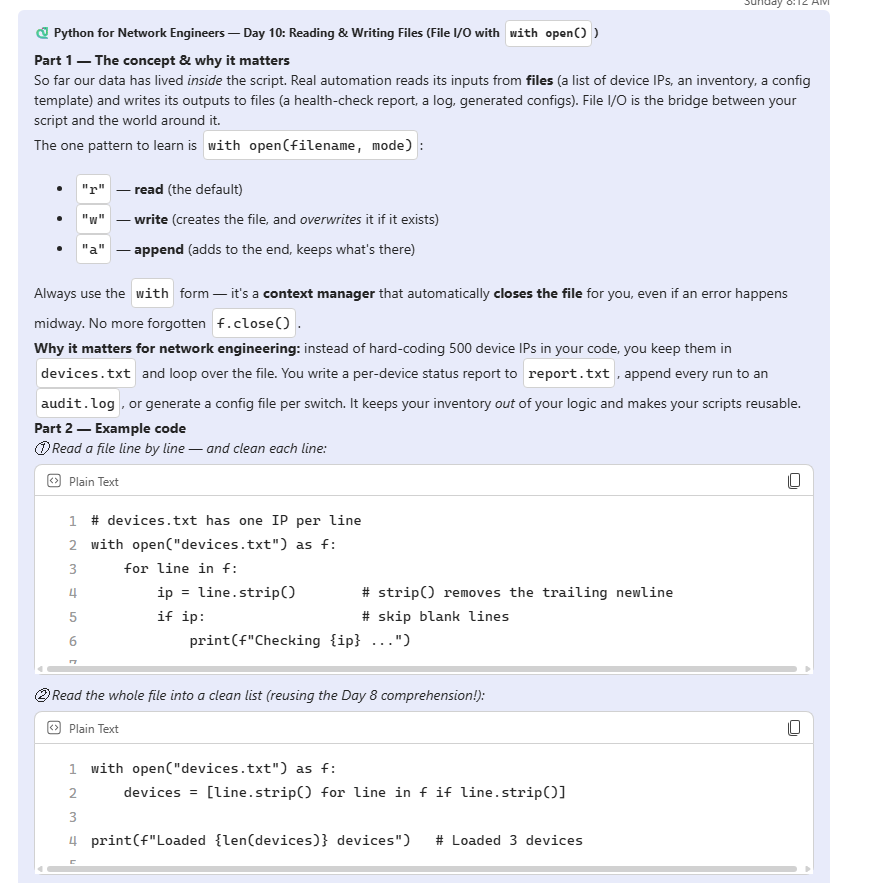


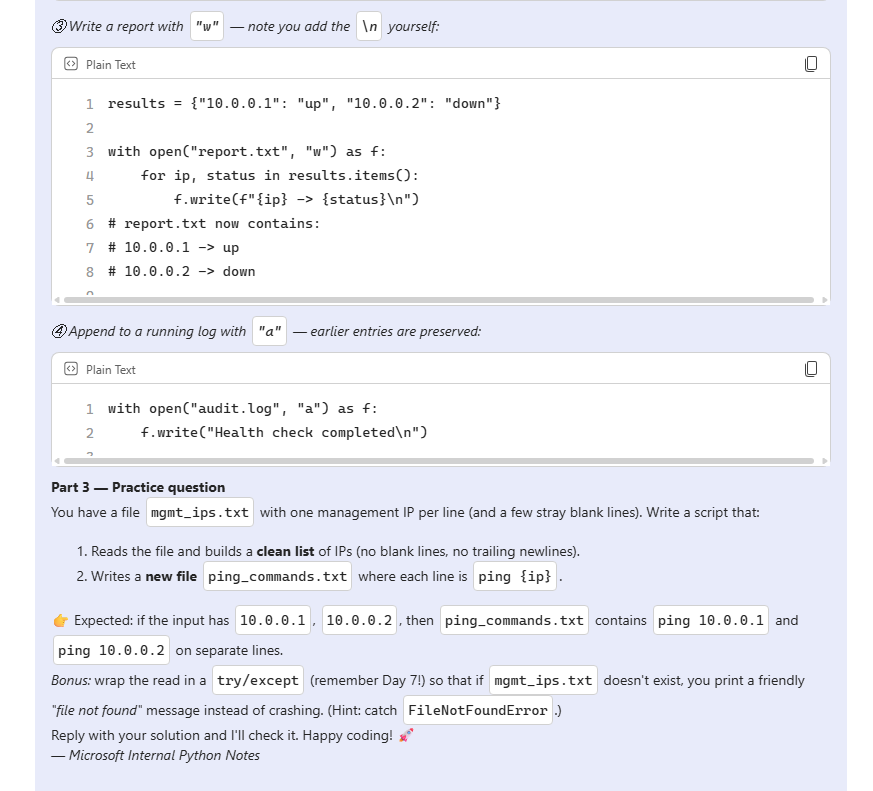

















In [15]:
# devices.txt has one IP per line
with open("devices.txt") as f:
    for line in f:
        ip = line.strip()        # strip() removes the trailing newline
        if ip:                   # skip blank lines
            print(f"Checking {ip} ...")


Checking 10.0.0.1 ...
Checking 10.0.0.2 ...
Checking 10.0.0.3 ...
Checking 10.0.0.4 ...
Checking 192.168.1.1 ...
Checking 192.168.1.2 ...
Checking # test entry (should be ignored by your logic if needed) ...
Checking 172.16.0.1 ...
Checking `` ...


In [1]:
with open("devices.txt") as f:
    for line in f:
        ip = line.strip()
        if ip:
            print(f"checking123 {ip} ...........................")

checking123 10.0.0.1 ...........................
checking123 10.0.0.2 ...........................
checking123 10.0.0.3 ...........................
checking123 10.0.0.4 ...........................
checking123 192.168.1.1 ...........................
checking123 192.168.1.2 ...........................
checking123 # test entry (should be ignored by your logic if needed) ...........................
checking123 172.16.0.1 ...........................
checking123 `` ...........................


In [2]:
with open("devices.txt") as f:
    for line in f:
        ip1 = line.strip()
        if ip1:
            print(f"checking123 {ip} ...........................")

checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................
checking123 `` ...........................


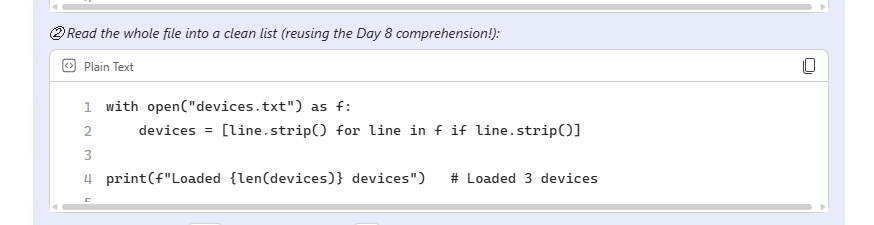

In [5]:
with open("devices.txt") as f:
    devices = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(devices)} devices")


Loaded 9 devices


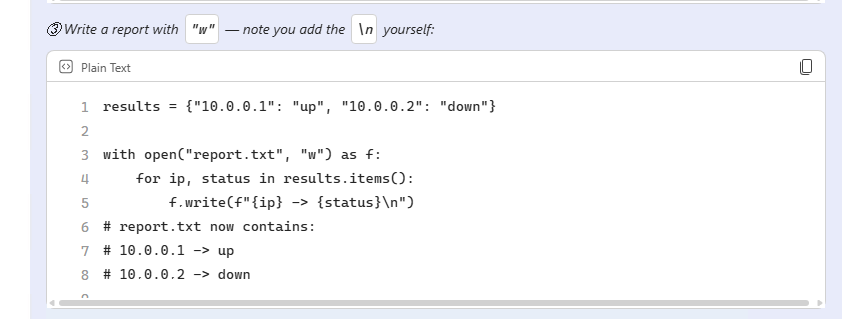

In [ ]:
results = {"10.0.0.1": "up", "10.0.0.2": "down"}

with open("report.txt", "w") as f:
    for ip, status in results.items():
        f.write(f"{ip} -> {status}\n")

#report.txt now contains:

In [7]:
with open("report.txt", "r") as m:
    reading_file = m.read()
    print(reading_file)


10.0.0.1 -> up
10.0.0.2 -> down



In [8]:
with open("report.txt", "r") as f:
    content = f.read()

print(content)

10.0.0.1 -> up
10.0.0.2 -> down



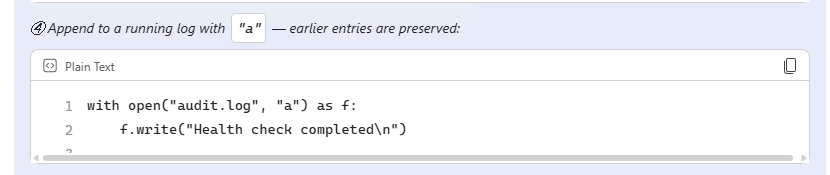

In [9]:
with open("audit.log", "a") as f:
    f.write("Health check completed\n")

In [10]:
with open("audit.log", "r") as audit_log_read:
    audit_log = audit_log_read.read()
    print(audit_log)

Health check completed



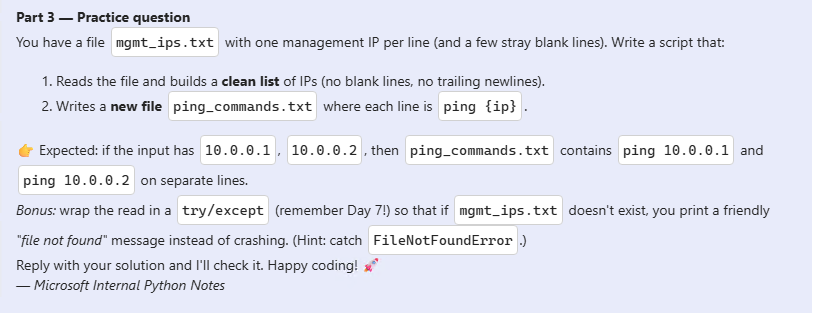

In [12]:
with open("report.txt") as read:
    for line in read:
        ip = line.strip()
        if ip:
            print(f"ping {ip}..")
    

ping 10.0.0.1 -> up..
ping 10.0.0.2 -> down..


In [14]:
with open("mgmt_ips.txt") as read:
    for line in read:
        ip = line.strip()
        if ip:
            print(f"ping {ip}")
    

ping 10.0.0.1
ping 10.0.0.2
ping 10.0.0.3
ping 10.0.0.4
ping 192.168.1.10
ping 172.16.0.5


In [ ]:
with open("mgmt_ips.txt") as read:
    for line in read:
        ip = line.strip()
        if ip:
            with open("ping_commands.txt" , "w") as f1:
    

In [15]:
try:
    with open("mgmt_ips.txt", "r") as f:
        ips = []

        for line in f:
            line = line.strip()  # remove \n and spaces
            if line:             # skip blank lines
                ips.append(line)

    with open("ping_commands.txt", "w") as f:
        for ip in ips:
            f.write(f"ping {ip}\n")

    print("ping_commands.txt created successfully")

except FileNotFoundError:
    print("File not found: mgmt_ips.txt")


ping_commands.txt created successfully


In [18]:
with open("ping_commands.txt", "r") as audit_log_read:
    audit_log = audit_log_read.read()
    print(audit_log)

ping 10.0.0.1
ping 10.0.0.2
ping 10.0.0.3
ping 10.0.0.4
ping 192.168.1.10
ping 172.16.0.5



In [16]:
with open("mgmt_ips.txt") as read:
    with open("ping_commands1.txt", "w") as write:
        for line in read:
            ip = line.strip()
            if ip:
                write.write(f"ping {ip}\n")

In [19]:
with open("ping_commands1.txt", "r") as audit_log_read:
    audit_log = audit_log_read.read()
    print(audit_log)

ping 10.0.0.1
ping 10.0.0.2
ping 10.0.0.3
ping 10.0.0.4
ping 192.168.1.10
ping 172.16.0.5



In [17]:
try:
    with open("mgmt_ips.txt") as read:
        with open("ping_commands2.txt", "w") as write:
            for line in read:
                ip = line.strip()
                if ip:
                    write.write(f"ping {ip}\n")

    print("File created successfully")

except FileNotFoundError:
    print("File not found: mgmt_ips.txt")

File created successfully


In [20]:
with open("ping_commands2.txt", "r") as audit_log_read:
    audit_log = audit_log_read.read()
    print(audit_log)

ping 10.0.0.1
ping 10.0.0.2
ping 10.0.0.3
ping 10.0.0.4
ping 192.168.1.10
ping 172.16.0.5




🐍 Python for Network Engineers — Day 11: Working with JSON (the json module)
Part 1 — The concept & why it matters
JSON (JavaScript Object Notation) is the universal language of modern network APIs. Whenever you talk to RESTCONF, Meraki, NetBox, DNA Center, or pull device telemetry, the data comes back as JSON text. The json module is the translator between that text and real Python objects you can work with.
The mapping is beautifully simple — JSON looks almost exactly like the Python you already know:
A JSON object { }  ⟷  a Python dict (remember Day 3!)
A JSON array [ ]  ⟷  a Python list (Day 2!)
true/false/null  ⟷  True/False/None
Four functions do all the work — and the naming is easy to remember (the s = "string"):
json.loads(text) — load string → parse JSON text into a Python dict/list
json.dumps(obj) — dump string → turn a Python object into a JSON text string
json.load(file) — read JSON straight from an open file
json.dump(obj, file) — write a Python object straight to an open file
Why it matters for network engineering: JSON is the bridge between "API response" and "data your script can act on." Instead of regex-scraping CLI text (Day 9), an API hands you clean structured data — you just json.loads() it and index into a dict. You'll also store inventories and config templates as .json files, and post JSON payloads back to devices to push config. This is the single most common data format you'll touch in real automation.
Part 2 — Example code
① json.loads — parse an API response string into a Python dict:
Plain Text
import json
# This is what a REST API typically returns: a string of JSON text
response = '{"hostname": "core-sw-01", "model": "C9300", "uptime_days": 142, "interfaces_up": 47}'
device = json.loads(response)     # string -> dict
print(type(device))               # <class 'dict'>
print(device["hostname"])         # core-sw-01
print(device["uptime_days"])      # 142

② json.dumps — turn a Python dict into JSON text (with indent= for clean, readable output):
Plain Text
inventory = {
    "site": "SEA",
    "devices": ["core-sw-01", "core-sw-02"],
    "managed": True,
}
# indent=2 pretty-prints it; without it you get one long line
print(json.dumps(inventory, indent=2))
# {
#   "site": "SEA",
#   "devices": [
#     "core-sw-01",
#     "core-sw-02"
#   ],
#   "managed": true        <-- note: Python True became JSON true
# }

③ Nested JSON — index in just like a nested dict (Day 3) and loop over an array:
Plain Text
api_text = '''
{
  "neighbors": [
    {"ip": "10.0.0.1", "state": "Established", "asn": 65001},
    {"ip": "10.0.0.2", "state": "Idle",        "asn": 65002}
  ]
}
'''
data = json.loads(api_text)
for nbr in data["neighbors"]:
    print(f"{nbr['ip']} (AS{nbr['asn']}) -> {nbr['state']}")
# 10.0.0.1 (AS65001) -> Established
# 10.0.0.2 (AS65002) -> Idle

④ Read & write JSON files (combining Day 10's with open()):
Plain Text
# Read an inventory file
with open("inventory.json") as f:
    inv = json.load(f)            # file -> dict, in one step
# ...modify it...
inv["last_audit"] = "2026-06-29"
# Write it back out, nicely formatted
with open("inventory.json", "w") as f:
    json.dump(inv, f, indent=2)   # dict -> file

Part 3 — Practice question
An API gives you this JSON string describing two interfaces:
Plain Text
raw = '''
{
  "device": "edge-rtr-02",
  "interfaces": [
    {"name": "Gi0/1", "status": "up",   "errors": 0},
    {"name": "Gi0/2", "status": "down", "errors": 17},
    {"name": "Gi0/3", "status": "up",   "errors": 3}
  ]
}
'''

👉 Parse it with json.loads, then loop over the interfaces list and print only the interfaces that are "down" OR have more than 0 errors, like:
Gi0/2 -> down (17 errors)
Gi0/3 -> up (3 errors)
Bonus: build a small Python dict summarizing the result — {"device": "edge-rtr-02", "problem_count": 2} — and print it as pretty JSON using json.dumps(..., indent=2).
Reply with your solution and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes


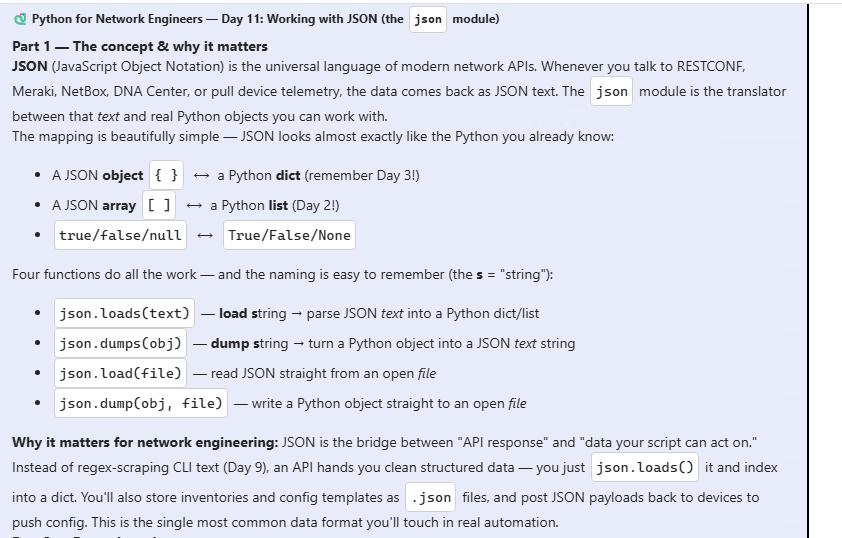

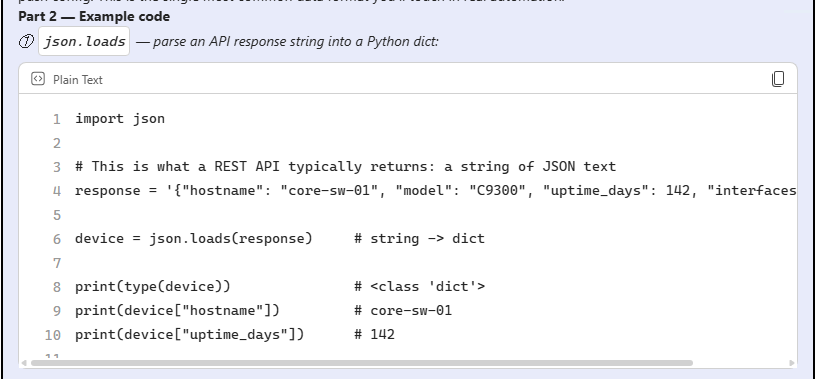

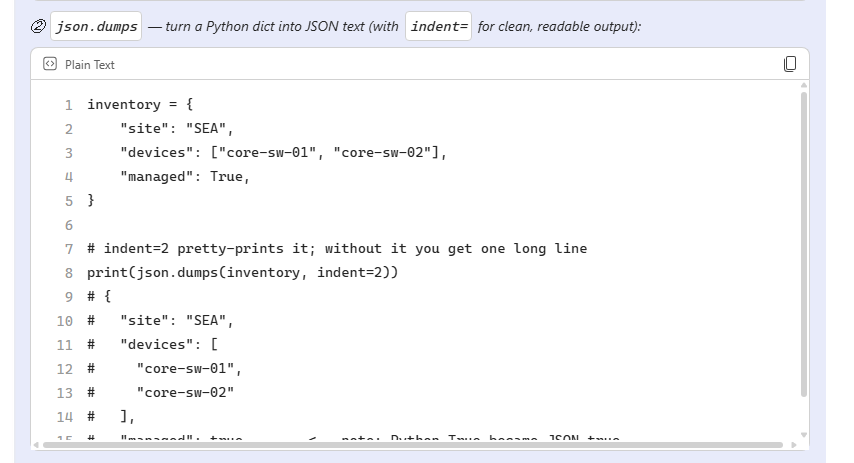
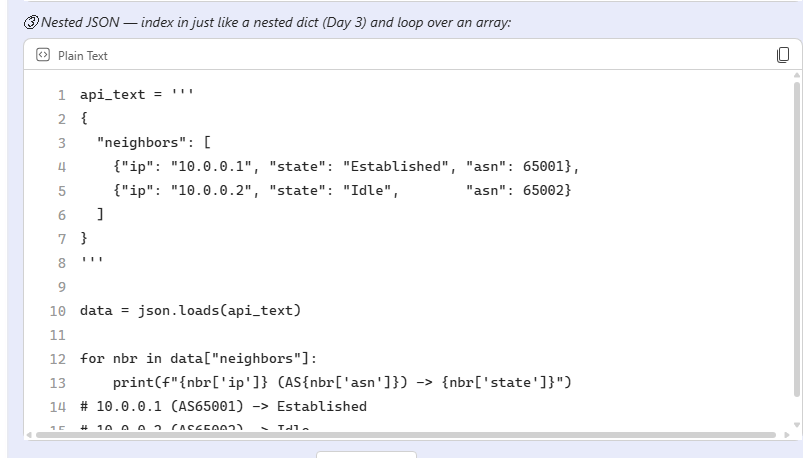
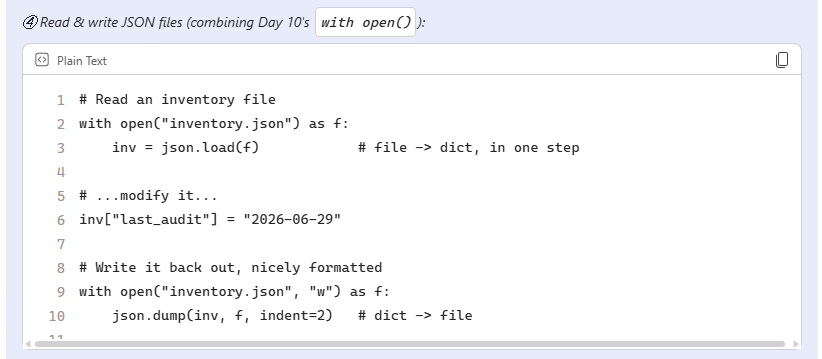

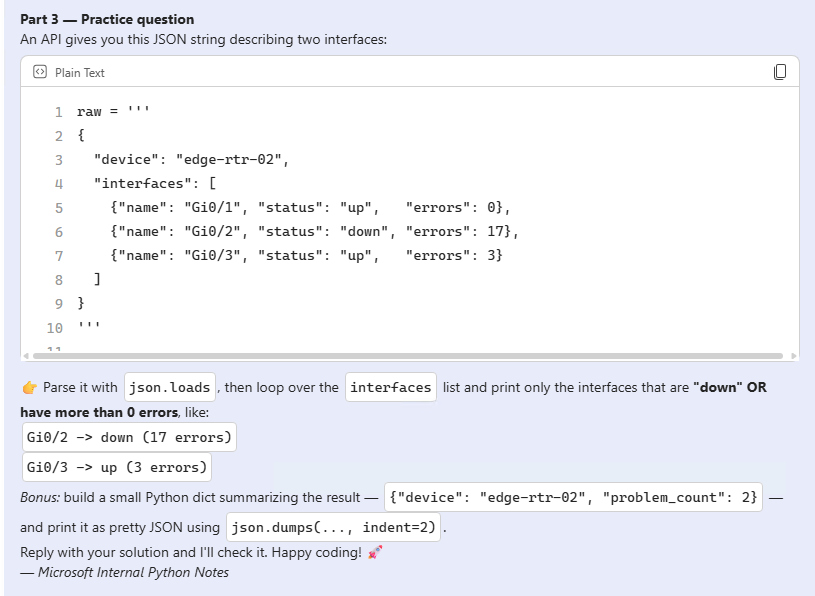



In [24]:
import json 

response = '{"hostname": "core-sw-01", "model": "C9300", "uptime_days": 142, "interfaces_up": 47}'

device = json.loads(response)

print(type(device))
print(device["hostname"])
print(device["uptime_days"])
print(device["interfaces_up"])

<class 'dict'>
core-sw-01
142
47


In [23]:
import json

# This is what a REST API typically returns: a string of JSON text
response = '{"hostname": "core-sw-01", "model": "C9300", "uptime_days": 142, "interfaces_up": 47}'

device = json.loads(response)     # string -> dict

print(type(device))               # <class 'dict'>
print(device["hostname"])         # core-sw-01
print(device["uptime_days"])      # 142


<class 'dict'>
core-sw-01
142


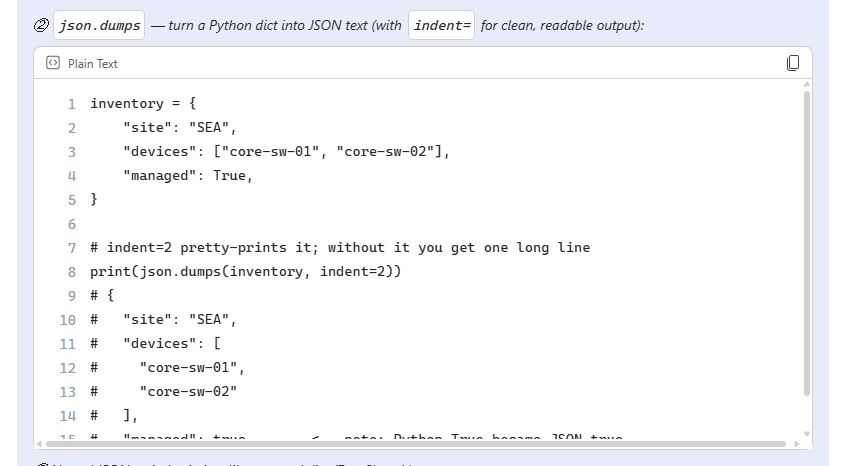

In [25]:
inventory = {
    "site": "SEA",
    "devices":["core-sw-01", "core-sw-02"],
    "managed": True,
}

print(json.dumps(inventory, indent=2))

{
  "site": "SEA",
  "devices": [
    "core-sw-01",
    "core-sw-02"
  ],
  "managed": true
}


In [27]:
inventory = {
    "site": "SEA",
    "devices":["core-sw-01", "core-sw-02"],
    "managed": True,
}

print(json.dumps(inventory, indent=10))

{
          "site": "SEA",
          "devices": [
                    "core-sw-01",
                    "core-sw-02"
          ],
          "managed": true
}


In [35]:
inventory1 = {
    "site": "SEA",
    "devices":["core-sw-01", "core-sw-02"],
    "managed": True,
    "vendor": ("cisco", "Juniper"),
    "hwsku":False,
    "performance":["low", 74584768]
}

print(json.dumps(inventory1, indent=2))

{
  "site": "SEA",
  "devices": [
    "core-sw-01",
    "core-sw-02"
  ],
  "managed": true,
  "vendor": [
    "cisco",
    "Juniper"
  ],
  "hwsku": false,
  "performance": [
    "low",
    74584768
  ]
}


In [28]:
inventory = {
    "site": "SEA",
    "devices": ["core-sw-01", "core-sw-02"],
    "managed": True,
}

# indent=2 pretty-prints it; without it you get one long line
print(json.dumps(inventory, indent=2))
# {
#   "site": "SEA",
#   "devices": [
#     "core-sw-01",
#     "core-sw-02"
#   ],
#   "managed": true        <-- note: Python True became JSON true
# }


{
  "site": "SEA",
  "devices": [
    "core-sw-01",
    "core-sw-02"
  ],
  "managed": true
}


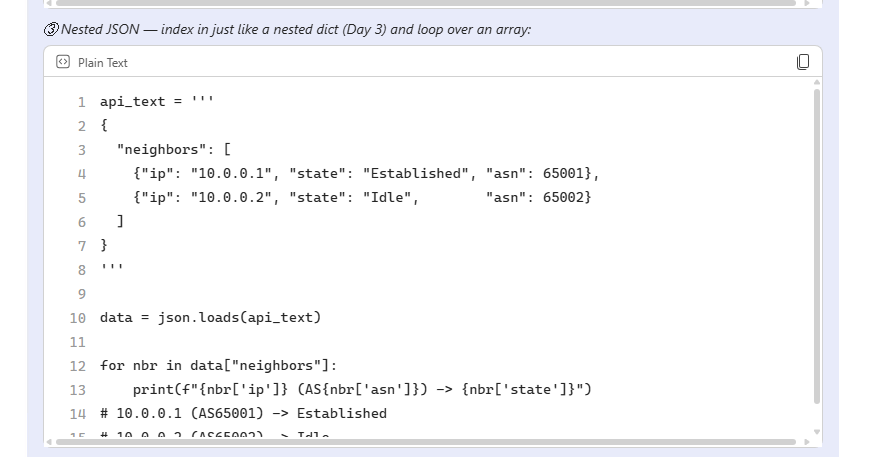

In [36]:
api_text = '''
{
  "neighbors": [
    {"ip": "10.0.0.1", "state": "Established", "asn": 65001},
    {"ip": "10.0.0.2", "state": "Idle",        "asn": 65002}
  ]
}
'''

data = json.loads(api_text)

for nbr in data["neighbors"]:
    print(f"{nbr['ip']} (AS{nbr['asn']}) -> {nbr['state']}")

10.0.0.1 (AS65001) -> Established
10.0.0.2 (AS65002) -> Idle


In [37]:
api_text = '''
{
  "neighbors": [
    {"ip": "10.0.0.1", "state": "Established", "asn": 65001},
    {"ip": "10.0.0.2", "state": "Idle",        "asn": 65002}
  ]
}
'''

data = json.loads(api_text)

for nbr in data["neighbors"]:
    print(f"{nbr['ip']} (AS{nbr['asn']}) -> {nbr['state']}")
# 10.0.0.1 (AS65001) -> Established
# 10.0.0.2 (AS65002) -> Idle


10.0.0.1 (AS65001) -> Established
10.0.0.2 (AS65002) -> Idle


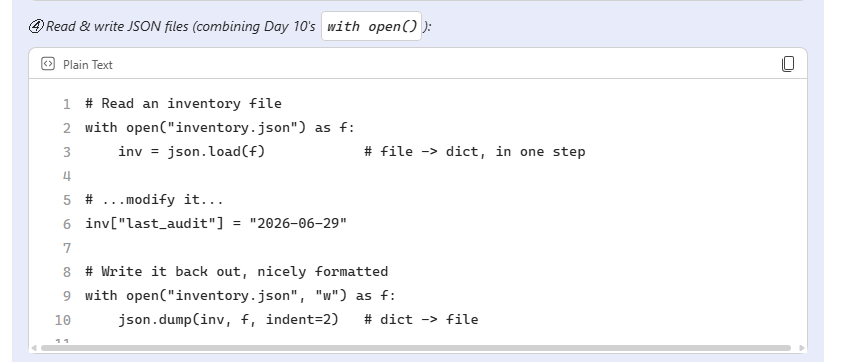

In [39]:
# Read an inventory file
with open("inventory.json") as f:
    inv = json.load(f)            # file -> dict, in one step

# ...modify it...
inv["last_audit"] = "2026-06-29"

# Write it back out, nicely formatted
with open("inventory.json", "w") as f:
    json.dump(inv, f, indent=2)   # dict -> file


In [40]:
import json

# Read JSON file
with open("inventory.json") as f:
    inv = json.load(f)

print("Before modification:")
print(json.dumps(inv, indent=2))

# Modify data
inv["last_audit"] = "2026-06-29"

# Write back to file
with open("inventory.json", "w") as f:
    json.dump(inv, f, indent=2)

print("\nAfter modification:")
print(json.dumps(inv, indent=2))

Before modification:
{
  "devices": [
    {
      "hostname": "rwa01",
      "mgmt_ip": "10.0.0.1",
      "vendor": "Juniper",
      "status": "up"
    },
    {
      "hostname": "ewa01",
      "mgmt_ip": "10.0.0.2",
      "vendor": "Cisco",
      "status": "up"
    },
    {
      "hostname": "ewa02",
      "mgmt_ip": "10.0.0.3",
      "vendor": "Arista",
      "status": "down"
    }
  ],
  "last_audit": "2026-06-29"
}

After modification:
{
  "devices": [
    {
      "hostname": "rwa01",
      "mgmt_ip": "10.0.0.1",
      "vendor": "Juniper",
      "status": "up"
    },
    {
      "hostname": "ewa01",
      "mgmt_ip": "10.0.0.2",
      "vendor": "Cisco",
      "status": "up"
    },
    {
      "hostname": "ewa02",
      "mgmt_ip": "10.0.0.3",
      "vendor": "Arista",
      "status": "down"
    }
  ],
  "last_audit": "2026-06-29"
}


In [42]:
import json

with open("inventory.json") as f:
    inv = json.load(f)

for device in inv["devices"]:
    if device["status"] == "down":
        print(device["hostname"], device["mgmt_ip"])

ewa02 10.0.0.3


For that exercise, create an **inventory.json** file like this:

```json
{
  "devices": [
    {
      "hostname": "rwa01",
      "mgmt_ip": "10.0.0.1",
      "vendor": "Juniper",
      "status": "up"
    },
    {
      "hostname": "ewa01",
      "mgmt_ip": "10.0.0.2",
      "vendor": "Cisco",
      "status": "up"
    },
    {
      "hostname": "ewa02",
      "mgmt_ip": "10.0.0.3",
      "vendor": "Arista",
      "status": "down"
    }
  ]
}
```

Then run this Python code:

```python
import json

# Read JSON file
with open("inventory.json") as f:
    inv = json.load(f)

print("Before modification:")
print(json.dumps(inv, indent=2))

# Modify data
inv["last_audit"] = "2026-06-29"

# Write back to file
with open("inventory.json", "w") as f:
    json.dump(inv, f, indent=2)

print("\nAfter modification:")
print(json.dumps(inv, indent=2))
```

### Output

```text
Before modification:
{
  "devices": [
    {
      "hostname": "rwa01",
      "mgmt_ip": "10.0.0.1",
      "vendor": "Juniper",
      "status": "up"
    },
    {
      "hostname": "ewa01",
      "mgmt_ip": "10.0.0.2",
      "vendor": "Cisco",
      "status": "up"
    },
    {
      "hostname": "ewa02",
      "mgmt_ip": "10.0.0.3",
      "vendor": "Arista",
      "status": "down"
    }
  ]
}

After modification:
{
  "devices": [
    {
      "hostname": "rwa01",
      "mgmt_ip": "10.0.0.1",
      "vendor": "Juniper",
      "status": "up"
    },
    {
      "hostname": "ewa01",
      "mgmt_ip": "10.0.0.2",
      "vendor": "Cisco",
      "status": "up"
    },
    {
      "hostname": "ewa02",
      "mgmt_ip": "10.0.0.3",
      "vendor": "Arista",
      "status": "down"
    }
  ],
  "last_audit": "2026-06-29"
}
```

### Network Automation Practice Challenge

Using the same `inventory.json`, print only devices that are down:

```python
import json

with open("inventory.json") as f:
    inv = json.load(f)

for device in inv["devices"]:
    if device["status"] == "down":
        print(device["hostname"], device["mgmt_ip"])
```

**Output**

```text
ewa02 10.0.0.3
```

This is a very realistic pattern for network automation: **JSON file → Python dictionary → process devices → update inventory → write back to JSON**.


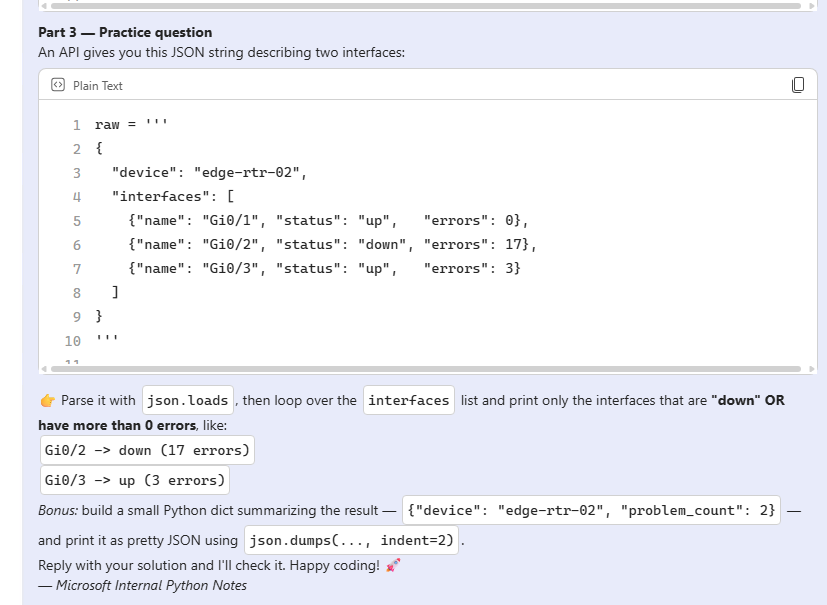

In [46]:
raw = '''
{
  "device": "edge-rtr-02",
  "interfaces": [
    {"name": "Gi0/1", "status": "up",   "errors": 0},
    {"name": "Gi0/2", "status": "down", "errors": 17},
    {"name": "Gi0/3", "status": "up",   "errors": 3}
  ]
}
'''

pratice = json.loads(raw)

for dev in pratice["device"]:
    if dev["status"] == "down" & dev["errors"] > 0:
        print(dev["name"], dev["errors"])

TypeError: string indices must be integers, not 'str'

In [48]:
raw = '''
{
  "device": "edge-rtr-02",
  "interfaces": [
    {"name": "Gi0/1", "status": "up",   "errors": 0},
    {"name": "Gi0/2", "status": "down", "errors": 17},
    {"name": "Gi0/3", "status": "up",   "errors": 3}
  ]
}
'''

pratice = json.loads(raw)

for dev in pratice["interfaces"]:
    if dev["status"] == "down" or dev["errors"] > 0:
        print(dev["name"], dev["errors"])

Gi0/2 17
Gi0/3 3


In [50]:
import json

raw = '''
{
    "device": "edge-rtr-02",
    "interfaces": [
        {"name": "Gi0/1", "status": "up", "errors": 0},
        {"name": "Gi0/2", "status": "down", "errors": 17},
        {"name": "Gi0/3", "status": "up", "errors": 3}
    ]
}
'''

pratice = json.loads(raw)

for dev in pratice["interfaces"]:
    if dev["status"] == "down" or dev["errors"] > 0:
        print(f'{dev["name"]} -> {dev["status"]} ({dev["errors"]} errors)')

Gi0/2 -> down (17 errors)
Gi0/3 -> up (3 errors)


In [52]:
import json

raw = '''
{
  "device": "edge-rtr-02",
  "interfaces": [
    {"name": "Gi0/1", "status": "up",   "errors": 0},
    {"name": "Gi0/2", "status": "down", "errors": 17},
    {"name": "Gi0/3", "status": "up",   "errors": 3}
  ]
}
'''

# Convert JSON string into a Python dictionary
data = json.loads(raw)

# Print interfaces that are down OR have more than 0 errors
problem_count = 0

for interface in data["interfaces"]:
    if interface["status"] == "down" or interface["errors"] > 0:
        print(
            f'{interface["name"]} -> {interface["status"]} '
            f'({interface["errors"]} errors)'
        )
        problem_count += 1

# Bonus: Create a summary dictionary
summary = {
    "device": data["device"],
    "problem_count": problem_count
}

# Pretty-print JSON
print("\nSummary:")
print(json.dumps(summary, indent=2))

Gi0/2 -> down (17 errors)
Gi0/3 -> up (3 errors)

Summary:
{
  "device": "edge-rtr-02",
  "problem_count": 2
}
